MNE Sample Dataset 新手预处理教程
==================================
基于 mne.datasets.sample 数据集，演示 EEG/MEG 数据从原始信号到 ERP 的完整预处理流程。

预处理步骤:
  1. 环境配置与数据加载
  2. 数据初步检查
  3. 选择感兴趣的通道
  4. 滤波
  5. 标记坏导
  6. 重参考（仅 EEG）
  7. ICA 伪迹去除
  8. 分段（Epoching）
  9. Epoch 质量控制与剔除
  10. 平均与结果可视化


In [ ]:
# =============================================================================
# Step 0: 初始化matplotlib
# =============================================================================
%matplotlib widget
import matplotlib
import matplotlib.pyplot as plt

# 列出所有可用的后端
print("matplotlib 内置后端:")
available_backends = matplotlib.backends.backend_registry.list_builtin(matplotlib.backends.BackendFilter.INTERACTIVE)
for i, backend in enumerate(available_backends):
    print(f"{backend:10}", end="\n" if (i + 1) % 5 == 0 else "")
print("\n")

# 查看当前后端
backend = matplotlib.get_backend()
print(f"当前后端: {backend}")


In [1]:
# =============================================================================
# Step 1: 环境配置与数据加载
# =============================================================================
import os
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt

data_dir = os.path.abspath("./datasets")
os.makedirs(data_dir, exist_ok=True)

# 每次运行强制更新 config
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)


print("config file =", mne.get_config_path())
# 打印config 内容,友好格式
config = mne.get_config()
for key, value in config.items():
    print(f"{key}: {value}")



sample_data_path = mne.datasets.sample.data_path(update_path=True)
raw_fname = sample_data_path / "MEG" / "sample" / "sample_audvis_raw.fif"


config file = /home/xiaoa/.mne/mne-python.json
MNE_DATA: /home/xiaoa/AI/ziyi/programs/my-eeg/src/datasets
MNE_DATASETS_SAMPLE_PATH: /home/xiaoa/AI/ziyi/programs/my-eeg/src/datasets


In [2]:
# =============================================================================
# Step 2: 加载原始数据 & 选择感兴趣的通道
# =============================================================================
# preload=True 将数据全部读入内存，方便后续就地修改
raw = mne.io.read_raw_fif(raw_fname, preload=True,verbose="warning")

# 选择感兴趣的通道
raw_eeg = raw.copy().pick(picks=["eeg"])  # 这个对象里只剩 EEG

# 查看基本信息：通道数、采样率、时长、通道类型等
# print(raw.info)
print(f"采样率: {raw_eeg.info['sfreq']} Hz")
print(f"通道数: {raw_eeg.info['nchan']}")
print(f"数据时长: {raw_eeg.times[-1]:.1f} 秒")
print(f"初始坏导列表: {raw_eeg.info['bads']}")


采样率: 600.614990234375 Hz
通道数: 60
数据时长: 277.7 秒
初始坏导列表: ['EEG 053']


In [ ]:
# =============================================================================
# Step 3: 绘制原始脑电的时域波形
# =============================================================================
# 查看原始脑电/脑磁信号的时域波形
raw_eeg_fig = raw_eeg.plot(duration=10, n_channels=20, title="Raw data browsing",show=True)
raw_eeg_fig.axes[0].set_title("Raw EEG Signal")


In [ ]:
# =============================================================================
# Step 4: 查看传感器布局（MEG 和 EEG 的空间分布）
# =============================================================================
fig, axes = plt.subplots(figsize=(5, 5))

eeg_sensors_fig = raw_eeg.plot_sensors(kind="topomap", axes=axes, show=True)
axes.set_title("EEG Sensor Layout")




In [ ]:
# ============================================================
# Step 5: 计算 PSD 并绘图
# ============================================================
fig, axes = plt.subplots(figsize=(14, 5))

# 计算原始EEG信号的功率谱密度（PSD）
eeg_psd = raw_eeg.compute_psd(fmax=80, picks="data", exclude="bads")
eeg_psd_fig = eeg_psd.plot(dB=True, amplitude=False, color='darkblue', average=True, ci = 'sd', axes=axes, show=False) 
axes.set_title("EEG Power Spectral Density")
# fig.tight_layout()

# 打印 PSD 关键参数
def print_spectrum_info(spec):
    """打印 Spectrum 对象的关键参数"""
    psd_data = spec.get_data()  # 返回 (n_channels, n_freqs) 的 numpy 数组

    print("=" * 40)
    print(f"计算方法: {spec.method}")
    print(f"频率范围: {spec.freqs[0]:.1f} - {spec.freqs[-1]:.1f} Hz")
    print(f"频率点数: {len(spec.freqs)}")
    print(f"通道数量: {len(spec.ch_names)}")
    print(f"频率分辨率: {spec.freqs[1] - spec.freqs[0]:.3f} Hz")
    print(f"PSD 形状: {psd_data.shape}")
    print("=" * 40)

print_spectrum_info(eeg_psd)

Effective window size : 3.410 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


Text(0.5, 1.0, 'After Filtering 1-40 Hz (EEG)')

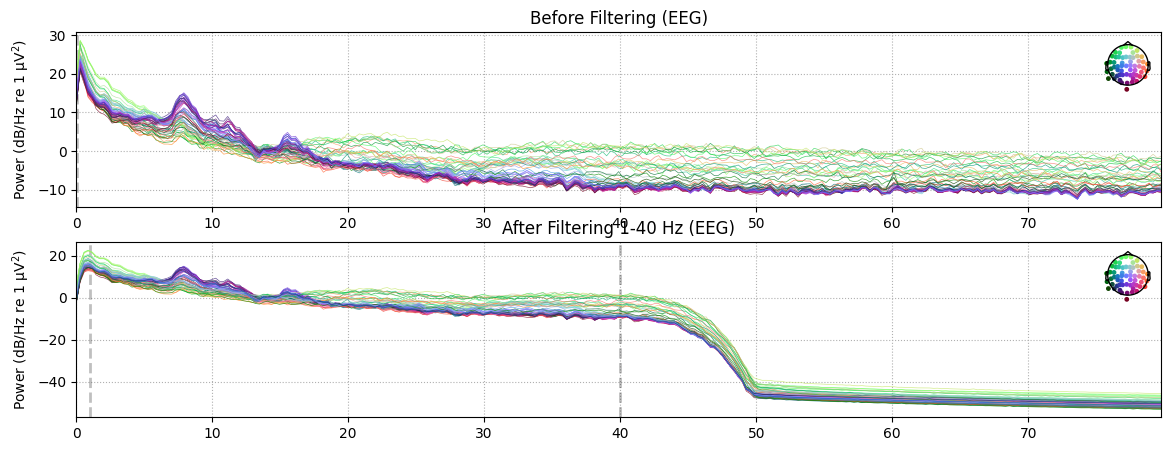

In [3]:
# =============================================================================
# Step 6: 对EEG滤波
# =============================================================================
# 滤波前
raw_eeg = raw.copy().pick(picks=["eeg"])
eeg_psd_before = raw_eeg.compute_psd(fmax=80)
# 滤波后（带通滤波）
raw_eeg_filtered = raw_eeg.filter(l_freq=1.0, h_freq=40.0)
eeg_psd_after = raw_eeg_filtered.compute_psd(fmax=80)



# 滤波前
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
a=eeg_psd_before.plot(picks="eeg", exclude="bads", axes=axes[0], show=False)
axes[0].set_title("Before Filtering (EEG)")
# 滤波后
b=eeg_psd_after.plot(picks="eeg", exclude="bads", axes=axes[1], show=False)
axes[1].set_title("After Filtering 1-40 Hz (EEG)")


In [ ]:
# =============================================================================
# Step 7: 手动标记坏导
# =============================================================================
# 坏导 = 信号质量差的通道（断线、持续噪声等）
# 坏导不会参与后续分析（ICA、平均等），避免污染结果
# Sample 数据集中已知的坏导：
raw.info["bads"] = ["MEG 2443", "EEG 053"]
print(f"标记的坏导: {raw.info['bads']}")

# # 继续添加其他坏导，如：
# #   - 其他断线通道
# #   - 其他噪声通道
# raw.info["bads"].extend(["MEG 2444", "EEG 054"])
# print(f"标记的坏导: {raw.info['bads']}")


In [4]:
# =============================================================================
# Step 8: 重参考（仅 EEG）
# =============================================================================
# EEG 信号是相对于参考电极的电位差，参考的选择会影响信号形态
# 常见参考方案：
#   - 平均参考（average）: 以所有 EEG 通道均值为参考，最常用
#   - 单电极参考: 如 Cz、鼻尖、耳垂等
# 这里使用平均参考
# projection=False 直接永久修改 EEG 信号，后续运算中无需再添加为投影
raw_eeg.set_eeg_reference("average", projection=False)
print("已设置 EEG 平均参考（非投影方式）")


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
已设置 EEG 平均参考（非投影方式）


Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 3.5s.
ICA 拟合完成，共 20 个成分


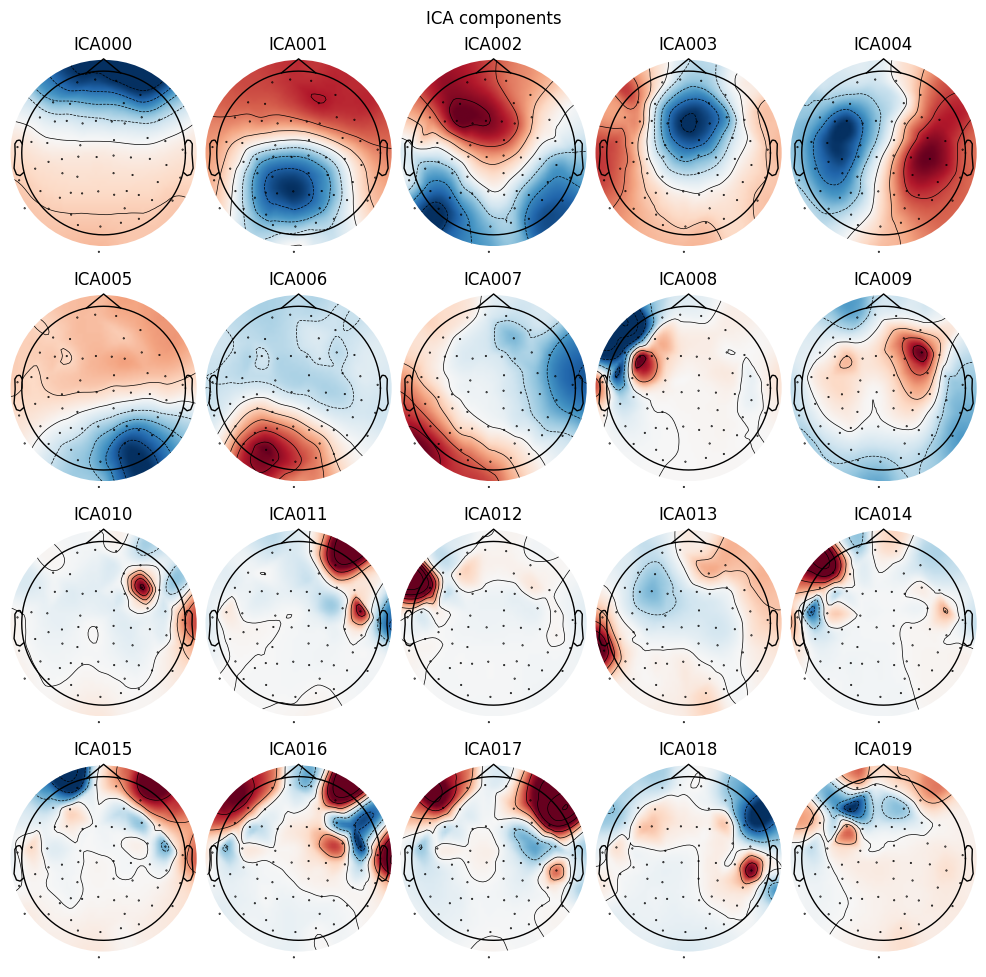

In [13]:
# =============================================================================
# Step 9: ICA 伪迹去除
# =============================================================================
# ICA（独立成分分析）将混合信号分解为统计独立的成分
# 眼动、心跳等伪迹通常集中在少数成分中，识别并去除即可

# 创建 ICA 对象
# n_components=20: 提取 20 个独立成分（通常 15-25 个足够）
# method='fastica': 快速 ICA 算法，适合新手
# random_state=42: 固定随机种子，保证结果可复现
ica = ICA(n_components=20, method="fastica", random_state=42)

# 拟合 ICA（在滤波后的连续数据上）
ica.fit(raw_eeg, picks=["eeg"])
print(f"ICA 拟合完成，共 {ica.n_components_} 个成分")

# 查看所有 ICA 成分的地形图（脑电空间分布）
# 眼动成分通常集中在前额区域，心跳成分呈现特征性分布
ica_fig = ica.plot_components(picks=range(20), inst=raw_eeg)
# 查看第 1 个 ICA 成分的属性（如功率谱）
# ica.plot_properties(picks=[1], inst=raw_eeg)

In [ ]:

# --- 自动识别眼动伪迹 (EOG) ---
# find_bads_eog 通过 EOG 通道与 ICA 成分的相关性来识别眼动成分
eog_indices, eog_scores = ica.find_bads_eog(raw_eeg)
print(f"自动识别的 EOG 伪迹成分: {eog_indices}")
ica.plot_scores(eog_scores, title="EOG 相关性得分")

# --- 自动识别心电伪迹 (ECG) ---
# Sample 数据没有 ECG 通道，MNE 会自动用 MEG 信号构造虚拟 ECG
ecg_indices, ecg_scores = ica.find_bads_ecg(raw)
print(f"自动识别的 ECG 伪迹成分: {ecg_indices}")
ica.plot_scores(ecg_scores, title="ECG 相关性得分")

# 汇总要排除的成分
ica.exclude = list(set(eog_indices + ecg_indices))
print(f"将要排除的 ICA 成分: {ica.exclude}")

# 查看要排除成分的时域波形（确认是否合理）
ica.plot_sources(raw, picks=ica.exclude)

# 应用 ICA，从原始数据中去除伪迹成分
# 注意：这会就地修改 raw 对象
ica.apply(raw)
print("ICA 伪迹去除完成")

Finding events on: STI 014


320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


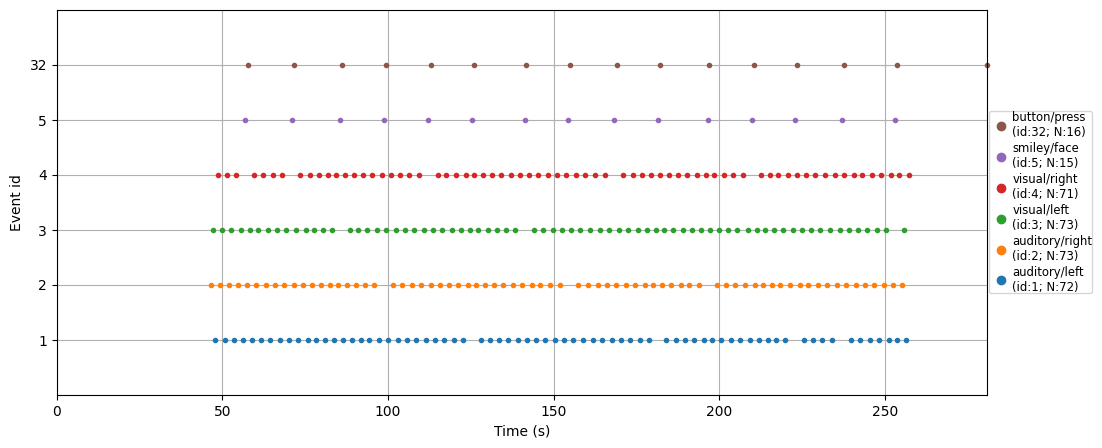

Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped
创建的 Epochs 数量: 320
各条件 Epoch 数:
  auditory/left: 72
  auditory/right: 73
  visual/left: 73
  visual/right: 71
  smiley/face: 15
  button/press: 16


In [50]:
# =============================================================================
# Step 10: 分段（Epoching）：events + epoch
# =============================================================================
# 从 stim 通道提取事件标记
# 注意：虽然之前 pick_types 时丢弃了 stim 通道，
# 但事件信息仍可从 raw 的 annotations 或重新加载中获取
# 这里我们重新读取事件（从原始文件的 stim 通道）
raw_for_events = mne.io.read_raw_fif(raw_fname, preload=False, verbose=False)
events = mne.find_events(raw_for_events, stim_channel="STI 014")
# shape(N, 3):(事件时间戳，事件类型，事件通道)

# 定义感兴趣的事件类型
# Sample 数据集包含听觉和视觉刺激，分左右耳/视野呈现
event_id = {
    "auditory/left": 1,   # 左耳听觉刺激
    "auditory/right": 2,  # 右耳听觉刺激
    "visual/left": 3,     # 左视野视觉刺激
    "visual/right": 4,    # 右视野视觉刺激
    "smiley/face": 5,     # 双眼看见笑脸😄
    "button/press": 32,    # 按下按钮
}

fig, ax = plt.subplots(figsize=(15, 5))
# 查看事件分布
event_plot = mne.viz.plot_events(events, sfreq=raw_for_events.info["sfreq"], event_id=event_id, axes=ax)

# 创建 Epochs（分段）
# tmin=-0.2: 刺激前 200ms（用作基线）
# tmax=0.5: 刺激后 500ms（ERP 主要成分出现区间）
# baseline=(None, 0): 基线校正，用 tmin 到 0 的均值做基线
#   基线校正原理：将每个 epoch 的信号减去基线期均值，
#   消除不同 trial 间的直流偏移差异
epochs = mne.Epochs(
    raw_for_events,
    events,
    event_id,
    tmin=-0.2,
    tmax=0.5,
    baseline=(None, 0),
    preload=True,
)
print(f"创建的 Epochs 数量: {len(epochs)}")
print(f"各条件 Epoch 数:")
for cond in event_id:
    print(f"  {cond}: {len(epochs[cond])}")


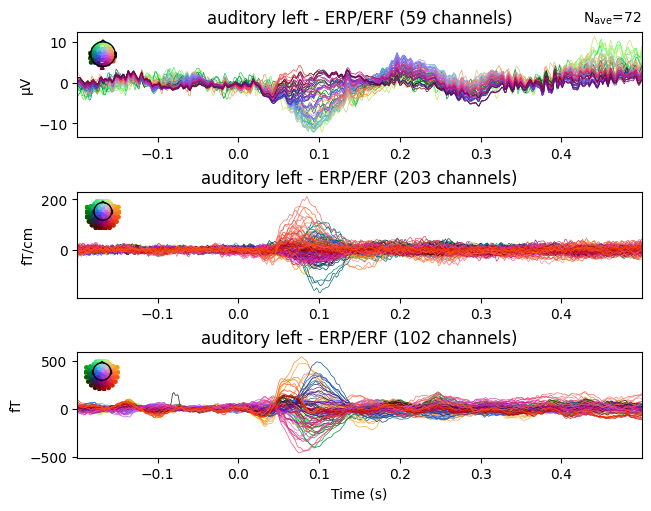

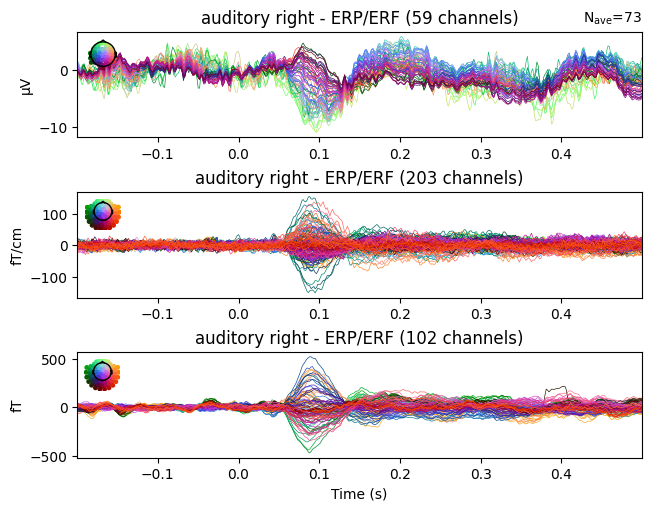

In [63]:
# =============================================================================
# Step 11: 平均与结果可视化
# =============================================================================
# 对各条件分别求平均，得到 ERP/ERF（事件相关电位/磁场）
# evoked_aud_l = epochs["auditory/left"].average()
# evoked_aud_r = epochs["auditory/right"].average()
# evoked_vis_l = epochs["visual/left"].average()
# evoked_vis_r = epochs["visual/right"].average()

# --- 波形图 ---
# 显示所有通道的时间波形
evoked_aud_l = epochs["auditory/left"].average()
evoked_aud_l_plt = evoked_aud_l.plot(titles="auditory left - ERP/ERF")

evoked_aud_r = epochs["auditory/right"].average()
evoked_aud_r_plt = evoked_aud_r.plot(titles="auditory right - ERP/ERF")


In [ ]:

# --- 地形图 ---
# 在多个时间点显示头皮电位/磁场分布
# 可以看到 N100、P200 等成分的空间分布
evoked_aud_l.plot_topomap(
    times=[0.05, 0.1, 0.15, 0.2],
    title="听觉左 - 地形图"
)

# --- 联合图（波形 + 地形图）---
# 最直观的展示方式：上方是波形，标记处显示对应时刻的地形图
evoked_aud_l.plot_joint(title="听觉左 - 联合图")
evoked_vis_l.plot_joint(title="视觉左 - 联合图")

# --- 条件对比 ---
# 比较不同实验条件的 ERP 差异
evokeds_compare = {
    "auditory/left": evoked_aud_l,
    "auditory/right": evoked_aud_r,
    "visual/left": evoked_vis_l,
    "visual/right": evoked_vis_r,
}
mne.viz.plot_compare_evokeds(
    evokeds_compare,
    picks="eeg",
    title="四种条件 ERP 对比 (EEG)",
)

# --- 听觉 vs 视觉 对比 ---
mne.viz.plot_compare_evokeds(
    {"auditory": evoked_aud_l, "visual": evoked_vis_l},
    picks="eeg",
    title="听觉 vs 视觉 ERP 对比 (EEG)",
)

print("\n预处理教程完成!")
print("关键成果:")
print(f"  - 原始数据: {raw_fname}")
print(f"  - 最终 Epochs 数量: {len(epochs)}")
print(f"  - ICA 排除成分: {ica.exclude}")
print(f"  - 生成 4 个条件的 ERP/ERF")


In [ ]:
# 重参考(投影)
raw.set_eeg_reference('average', projection=True)

# 3. 提取事件（events）
events = mne.find_events(raw, stim_channel='STI 014')

# 4. 定义事件ID
event_id = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
}

# 5. 从 raw + events 创建 epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin=-0.2,       # 事件前 0.2 秒
    tmax=0.5,         # 事件后 0.5 秒
    baseline=(-0.2, 0),  # 基线校正区间
    preload=True,       # 数据加载到内存
    picks=['eeg']
)

# 6. 现在可以画图了
# epochs.plot() # 绘制每个 epoch 的时间序列图
# epochs.plot_image() # 热力图（试次x时间）
epochs.plot_psd() # 功率谱密度图
